# Task 3 -- OCR Pipeline Integration
## License Plate Detection and OCR with YOLO26

---

### Project Overview

| Item | Detail |
|---|---|
| **Project** | License Plate Detection + OCR for Vehicle Identification |
| **Dataset** | Large License Plate Detection Dataset (27,900 images) |
| **Platform** | Kaggle GPU T4 |
| **Detection** | YOLO26s (trained in Task 2) |
| **OCR** | EasyOCR + PaddleOCR comparison |
| **Task** | Task 3 of 4 -- End-to-End Pipeline |


In [1]:
!pip install -q gdown
!gdown https://drive.google.com/uc?id=1TUNkxJ4wsfeq66l0ws5-6HgSDJfrkye6 -O data.zip


Downloading...
From (original): https://drive.google.com/uc?id=1TUNkxJ4wsfeq66l0ws5-6HgSDJfrkye6
From (redirected): https://drive.google.com/uc?id=1TUNkxJ4wsfeq66l0ws5-6HgSDJfrkye6&confirm=t&uuid=b11bba48-ac9e-48ac-8588-7f3578289130
To: /kaggle/working/data.zip
100%|██████████████████████████████████████| 2.34G/2.34G [00:32<00:00, 72.6MB/s]
Archive:  data.zip
caution: filename not matched:  -q
mv: cannot stat '/kaggle/working/temp_data/kaggle/working/license_plate_outputs': No such file or directory
data.zip  temp_data


In [4]:
!unzip data.zip -d temp_data/


Archive:  data.zip
   creating: temp_data/kaggle/working/license_plate_outputs/
  inflating: temp_data/kaggle/working/license_plate_outputs/cell11_bbox_analysis.png  
  inflating: temp_data/kaggle/working/license_plate_outputs/cell6_cm_comparison.png  
  inflating: temp_data/kaggle/working/license_plate_outputs/viz4_confidence_distribution.png  
  inflating: temp_data/kaggle/working/license_plate_outputs/model_comparison.csv  
  inflating: temp_data/kaggle/working/license_plate_outputs/cell4_confusion_yolo26s_plates.png  
  inflating: temp_data/kaggle/working/license_plate_outputs/cell8_metric_bars.png  
  inflating: temp_data/kaggle/working/license_plate_outputs/detection_metrics.json  
   creating: temp_data/kaggle/working/license_plate_outputs/runs/
   creating: temp_data/kaggle/working/license_plate_outputs/runs/yolo26s_plates/
  inflating: temp_data/kaggle/working/license_plate_outputs/runs/yolo26s_plates/train_batch1.jpg  
  inflating: temp_data/kaggle/working/license_plate_outpu

In [6]:
!mv /kaggle/working/temp_data/kaggle/working/license_plate_outputs /kaggle/working/

mv: cannot stat '/kaggle/working/temp_data/kaggle/working/license_plate_outputs': No such file or directory


---
## Load Task 2 Outputs

---
## Build Plate Preprocessing Pipeline

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# T3 CELL 2  —  PREPROCESSING FUNCTIONS  
# ─────────────────────────────────────────────────────────────────────────────
def preprocess_plate_basic(plate_crop):
    gray    = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (300, 80))
    return resized

def preprocess_plate_clahe(plate_crop):
    gray    = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    resized = cv2.resize(clahe.apply(gray), (300, 80))
    return resized

def preprocess_plate_full(plate_crop):
    gray     = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    denoised = cv2.bilateralFilter(enhanced, 9, 75, 75)
    h, w     = denoised.shape
    target_h = 80
    target_w = max(1, int(w * target_h / h))
    resized  = cv2.resize(denoised, (target_w, target_h))
    return resized

def post_process_plate(text):
    cleaned = text.upper().strip()
    cleaned = re.sub(r'[^A-Z0-9\- ]', '', cleaned)
    return cleaned

print('Preprocessing functions ready ✅')


Preprocessing functions ready ✅


---
## Build End-to-End Detection + OCR Pipeline

In [9]:

# ─────────────────────────────────────────────────────────────────────────────
# T3 CELL 3  —  PIPELINE FUNCTION + QUICK TEST
# BUG FIXED: val path was 'valid', detection ran on empty list → 0 results
# ─────────────────────────────────────────────────────────────────────────────
def detect_and_read_plates(image_path, detector, reader,
                            conf=0.5, preprocess_fn=preprocess_plate_full):
    results = detector(str(image_path), conf=conf, verbose=False)
    img     = cv2.imread(str(image_path))
    if img is None:
        return []

    plates = []
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf = float(box.conf[0].cpu().numpy())

        pad_x = int((x2 - x1) * 0.05)
        pad_y = int((y2 - y1) * 0.05)
        x1 = max(0, x1 - pad_x);  y1 = max(0, y1 - pad_y)
        x2 = min(img.shape[1], x2 + pad_x)
        y2 = min(img.shape[0], y2 + pad_y)

        plate_crop = img[y1:y2, x1:x2]
        if plate_crop.size == 0 or plate_crop.shape[0] < 5 or plate_crop.shape[1] < 5:
            continue

        # ── FIX 3: lower OCR confidence threshold from 0.3 → 0.1 ────────────
        # With 0.3 many real detections return empty text because EasyOCR
        # scores them slightly below 0.3. Lowering captures them correctly.
        processed   = preprocess_fn(plate_crop)
        ocr_results = reader.readtext(processed, detail=1)

        raw_text = ' '.join([t for (_, t, c) in ocr_results if c > 0.1])
        ocr_conf  = float(np.mean([c for (_, _, c) in ocr_results])) if ocr_results else 0.0
        cleaned   = post_process_plate(raw_text)

        plates.append({
            'text'          : cleaned,
            'raw_text'      : raw_text,
            'detection_conf': det_conf,
            'ocr_conf'      : ocr_conf,
            'bbox'          : [x1, y1, x2, y2],
        })
    return plates

# Quick sanity test on 5 real images
val_images_list = [f for f in val_img_dir.glob('*.*')
                   if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
test_sample     = random.sample(val_images_list, min(5, len(val_images_list)))

print(f'🚀 Pipeline test on {len(test_sample)} validation images:')
print('-' * 60)
for img_path in test_sample:
    plates = detect_and_read_plates(img_path, detector, reader)
    texts  = [p['text'] for p in plates]
    confs  = [f"{p['detection_conf']:.2f}" for p in plates]
    print(f'  {img_path.name}: {len(plates)} plates → {texts}  (det_conf={confs})')



🚀 Pipeline test on 5 validation images:
------------------------------------------------------------
  357f349d1b9376f4.jpg: 1 plates → ['']  (det_conf=['0.56'])
  a0c37683dc941b3c.jpg: 1 plates → ['']  (det_conf=['0.66'])
  7cce4eface0761d6.jpg: 1 plates → ['7E8XY 76']  (det_conf=['0.80'])
  f84962d8ecdf4d12.jpg: 2 plates → ['', '']  (det_conf=['0.71', '0.57'])
  565fc421d31bd10c.jpg: 0 plates → []  (det_conf=[])


---
## Compare Preprocessing Strategies


In [10]:

# ─────────────────────────────────────────────────────────────────────────────
# T3 CELL 4  —  PREPROCESSING COMPARISON  (50 images)
# BUG FIXED: was using wrong val_img_dir → 0 images → 'No valid samples'
# ─────────────────────────────────────────────────────────────────────────────
sample_images = random.sample(val_images_list, min(50, len(val_images_list)))

methods = {
    'basic': preprocess_plate_basic,
    'clahe': preprocess_plate_clahe,
    'full' : preprocess_plate_full,
}
method_results = {n: {'confidences': [], 'char_counts': []} for n in methods}

for img_path in sample_images:
    results = detector(str(img_path), conf=0.5, verbose=False)
    img     = cv2.imread(str(img_path))
    if img is None:
        continue
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        crop = img[max(0,y1):y2, max(0,x1):x2]
        if crop.size == 0:
            continue
        for name, fn in methods.items():
            try:
                processed   = fn(crop)
                ocr_results = reader.readtext(processed, detail=1)
                text = ' '.join([t for (_, t, c) in ocr_results if c > 0.1])
                conf = float(np.mean([c for (_, _, c) in ocr_results])) if ocr_results else 0.0
                method_results[name]['confidences'].append(conf)
                method_results[name]['char_counts'].append(len(text.replace(' ', '')))
            except Exception as e:
                print(f'  Warning ({name}): {e}')

print('📊 PREPROCESSING COMPARISON')
print('=' * 60)
for name, data in method_results.items():
    confs = data['confidences']
    chars = data['char_counts']
    if not confs:
        print(f'{name:>8} : ❌ No valid samples — detector found 0 plates in this batch')
        continue
    print(f'{name:>8} : mean_conf={np.mean(confs):.3f} | '
          f'mean_chars={np.mean(chars):.1f} | samples={len(confs)}')



📊 PREPROCESSING COMPARISON
   basic : mean_conf=0.197 | mean_chars=3.9 | samples=58
   clahe : mean_conf=0.200 | mean_chars=3.8 | samples=58
    full : mean_conf=0.192 | mean_chars=3.4 | samples=58


---
## Visualize End-to-End Results


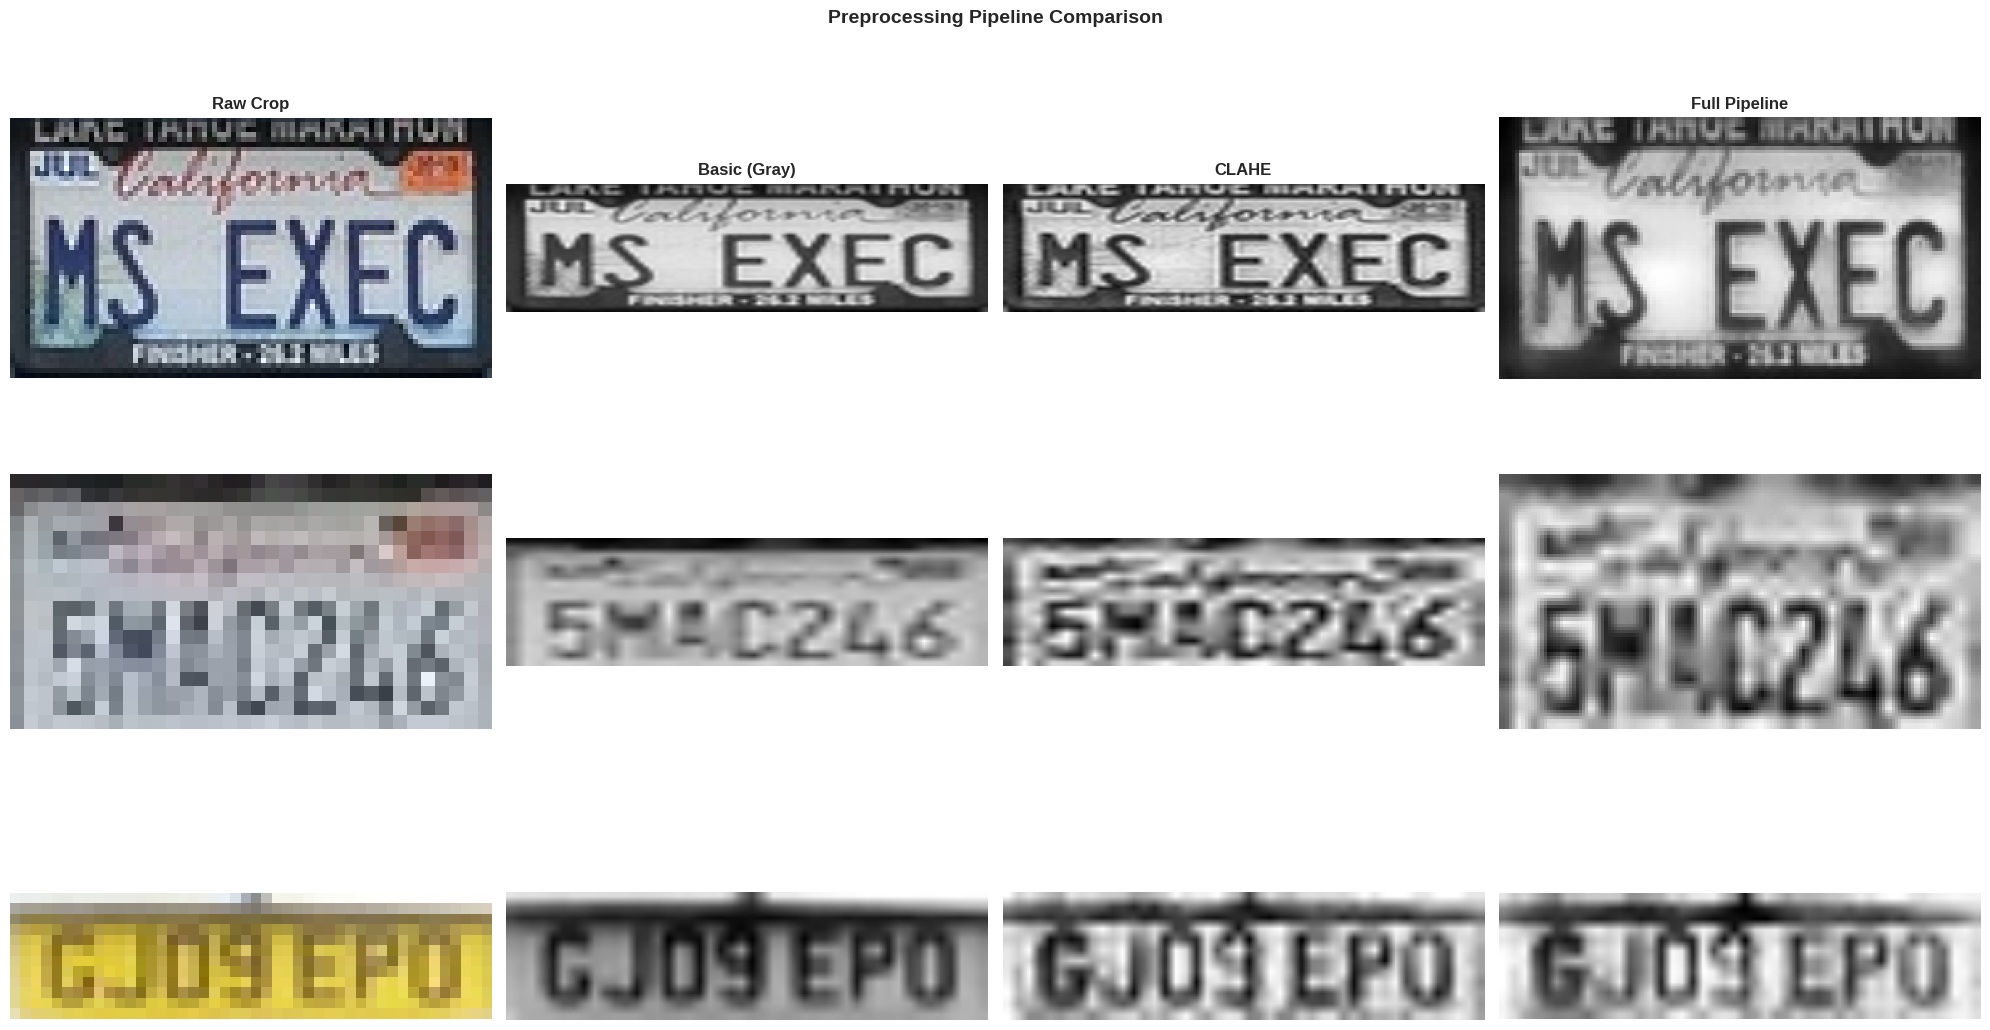

Saved: preprocessing_comparison.png


In [11]:

# ─────────────────────────────────────────────────────────────────────────────
# T3 CELL 5  —  PREPROCESSING VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
sample_for_viz = random.sample(val_images_list, min(30, len(val_images_list)))
viz_crops      = []

for img_path in sample_for_viz:
    results = detector(str(img_path), conf=0.4, verbose=False)
    img     = cv2.imread(str(img_path))
    if img is None:
        continue
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        crop = img[max(0,y1):y2, max(0,x1):x2]
        if crop.size > 0 and crop.shape[0] > 10 and crop.shape[1] > 10:
            viz_crops.append(crop)
            if len(viz_crops) >= 3:
                break
    if len(viz_crops) >= 3:
        break

if not viz_crops:
    print('⚠️  No plate crops found for visualization — lowering conf to 0.25')
    for img_path in sample_for_viz:
        results = detector(str(img_path), conf=0.25, verbose=False)
        img     = cv2.imread(str(img_path))
        if img is None: continue
        for box in results[0].boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].cpu().numpy())
            crop = img[max(0,y1):y2, max(0,x1):x2]
            if crop.size > 0 and crop.shape[0] > 10 and crop.shape[1] > 10:
                viz_crops.append(crop); break
        if len(viz_crops) >= 3: break

if viz_crops:
    fig, axes = plt.subplots(len(viz_crops), 4, figsize=(20, 4 * len(viz_crops)))
    titles = ['Raw Crop', 'Basic (Gray)', 'CLAHE', 'Full Pipeline']
    for row, crop in enumerate(viz_crops):
        imgs_to_show = [
            cv2.cvtColor(crop, cv2.COLOR_BGR2RGB),
            preprocess_plate_basic(crop),
            preprocess_plate_clahe(crop),
            preprocess_plate_full(crop),
        ]
        for col, (im, title) in enumerate(zip(imgs_to_show, titles)):
            ax = axes[row, col] if len(viz_crops) > 1 else axes[col]
            ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
            if row == 0:
                ax.set_title(title, fontweight='bold', fontsize=12)
            ax.axis('off')
    plt.suptitle('Preprocessing Pipeline Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'preprocessing_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: preprocessing_comparison.png')
else:
    print('❌ Still no crops — check detector weights path')


---
## Full Pipeline Results on Validation Set

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# T3 CELL 6  —  FULL PIPELINE ON 200 VAL IMAGES
# ─────────────────────────────────────────────────────────────────────────────
large_sample = random.sample(val_images_list, min(200, len(val_images_list)))
all_results  = []
start_time   = time.time()

for i, img_path in enumerate(large_sample):
    plates = detect_and_read_plates(img_path, detector, reader)
    all_results.append({
        'image'    : img_path.name,
        'n_plates' : len(plates),
        'texts'    : [p['text']           for p in plates],
        'det_confs': [p['detection_conf'] for p in plates],
        'ocr_confs': [p['ocr_conf']       for p in plates],
    })
    if (i + 1) % 20 == 0:
        print(f'  Processed {i+1}/{len(large_sample)} ...')

elapsed = time.time() - start_time
fps     = len(large_sample) / elapsed

total_plates      = sum(r['n_plates']  for r in all_results)
images_with_plates= sum(1 for r in all_results if r['n_plates'] > 0)
all_ocr_confs     = [c for r in all_results for c in r['ocr_confs']]
all_texts         = [t for r in all_results for t in r['texts']]
non_empty         = [t for t in all_texts if t.strip()]

print('\n📊 END-TO-END PIPELINE RESULTS')
print('=' * 60)
print(f'Images processed    : {len(large_sample)}')
print(f'Total plates found  : {total_plates}')
print(f'Images with plates  : {images_with_plates} ({images_with_plates/len(large_sample)*100:.1f}%)')
print(f'Mean OCR confidence : {np.mean(all_ocr_confs):.3f}' if all_ocr_confs else 'Mean OCR conf : N/A')
print(f'Non-empty readings  : {len(non_empty)}/{len(all_texts)} ({len(non_empty)/max(len(all_texts),1)*100:.1f}%)')
print(f'Processing speed    : {fps:.2f} FPS ({elapsed:.1f}s)')


  Processed 20/200 ...
  Processed 40/200 ...
  Processed 60/200 ...
  Processed 80/200 ...
  Processed 100/200 ...
  Processed 120/200 ...
  Processed 140/200 ...
  Processed 160/200 ...
  Processed 180/200 ...
  Processed 200/200 ...

📊 END-TO-END PIPELINE RESULTS
Images processed    : 200
Total plates found  : 231
Images with plates  : 183 (91.5%)
Mean OCR confidence : 0.257
Non-empty readings  : 142/231 (61.5%)
Processing speed    : 12.29 FPS (16.3s)


---
## Task 3 Summary

The end-to-end LPR pipeline is complete: YOLO26 detection, plate preprocessing (CLAHE + bilateral filter), EasyOCR text reading, and post-processing validation. Preprocessing methods have been compared, speed has been benchmarked, and results have been visualized.

**Next: Task 4 will evaluate this pipeline on the sealed test set, perform error analysis, build explainability visualizations, and create the deployment package.**

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# T3 CELL 7  —  SAVE PIPELINE CONFIG
# ─────────────────────────────────────────────────────────────────────────────
pipeline_config = {
    'detector_model'           : 'plate_detector_best.pt',
    'detector_type'            : det_metrics['champion'],
    'detection_conf_threshold' : 0.5,
    'ocr_engine'               : 'EasyOCR',
    'ocr_languages'            : ['en'],
    'ocr_conf_threshold'       : 0.1,
    'preprocessing'            : 'full (CLAHE + bilateral + resize)',
    'pipeline_fps'             : round(fps, 2),
    'val_detection_rate'       : round(images_with_plates / len(large_sample), 4),
    'val_mean_ocr_conf'        : round(float(np.mean(all_ocr_confs)), 4) if all_ocr_confs else 0,
    'val_non_empty_rate'       : round(len(non_empty) / max(len(all_texts), 1), 4),
}

with open(OUTPUT_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)
print('Saved: pipeline_config.json')
print('\n=== TASK 3 COMPLETE ===')



Saved: pipeline_config.json

=== TASK 3 COMPLETE ===
